In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import re
import os

BASE = '/content/drive/MyDrive/edtech_absa'

# Load cleaned data
df = pd.read_csv(f'{BASE}/data/processed/reviews_cleaned.csv')
print(f"Loaded {len(df)} reviews")
print(df.columns.tolist())

Mounted at /content/drive
Loaded 12455 reviews
['platform', 'country', 'region', 'review_id', 'text', 'rating', 'date', 'thumbs_up', 'text_clean', 'word_count']


In [2]:
import spacy
nlp = spacy.load('en_core_web_sm')

def split_into_sentences(text):
    doc = nlp(str(text))
    # Return sentences with at least 5 words — ignore fragments
    return [sent.text.strip() for sent in doc.sents if len(sent.text.split()) >= 5]

print("Splitting reviews into sentences...")
print("This takes ~2 minutes for 12,500 reviews...\n")

# Apply sentence splitting
df['sentences'] = df['text_clean'].apply(split_into_sentences)

# Explode — each sentence becomes its own row
# We keep all original columns so we know which platform/region it came from
df_sentences = df.explode('sentences').rename(columns={'sentences': 'sentence'})
df_sentences = df_sentences.dropna(subset=['sentence'])
df_sentences = df_sentences[df_sentences['sentence'].str.strip() != '']
df_sentences = df_sentences.reset_index(drop=True)

print(f"Reviews:   {len(df)}")
print(f"Sentences: {len(df_sentences)}")
print(f"Avg sentences per review: {len(df_sentences)/len(df):.1f}")
print(f"\nSample sentences:")
print(df_sentences['sentence'].head(10).tolist())

Splitting reviews into sentences...
This takes ~2 minutes for 12,500 reviews...

Reviews:   12455
Sentences: 45973
Avg sentences per review: 3.7

Sample sentences:
['i really like the idea of further learning, but for this platform to provide all the different nearing materials, technology to be exact.', 'but then their not able to link accounts.', 'or denying refunds on transactions they again screwed up.', 'i was going to rate after i finished my course, and experienced the change i. my resume.', 'but, they messed with my money.', 'not difficult to rate them then.', 'coursera used to be such a great website and app.', 'but as of a few months ago they got rid of virtually all free content.', 'before, you could learn a course for free but needed to pay to get a certificate.', 'now you can only learn the first week for free.']


In [3]:
ASPECT_KEYWORDS = {
    'Content_Quality': [
        'content', 'material', 'curriculum', 'course quality', 'outdated',
        'up to date', 'depth', 'accurate', 'comprehensive', 'syllabus',
        'exercises', 'projects', 'examples', 'real world', 'topic',
        'module', 'chapter', 'lesson', 'theory', 'practical'
    ],
    'Instructor': [
        'instructor', 'teacher', 'professor', 'tutor', 'explains',
        'teaching', 'lecture', 'voice', 'presentation', 'knowledgeable',
        'boring', 'engaging', 'pace', 'monotone', 'passionate',
        'clear', 'expert', 'coach', 'trainer', 'mentor'
    ],
    'Platform_UX': [
        'app', 'interface', 'ui', 'ux', 'website', 'mobile', 'download',
        'video quality', 'playback', 'speed', 'buffering', 'navigation',
        'design', 'loading', 'crash', 'offline', 'stream', 'player',
        'feature', 'update', 'bug', 'glitch', 'smooth', 'slow'
    ],
    'Pricing': [
        'price', 'cost', 'expensive', 'cheap', 'subscription', 'free',
        'discount', 'refund', 'worth', 'value', 'money', 'pay', 'fee',
        'affordable', 'overpriced', 'billing', 'charge', 'plan', 'tier',
        'premium', 'trial', 'cancel'
    ],
    'Support': [
        'support', 'customer service', 'help', 'response', 'reply',
        'team', 'issue', 'problem', 'contact', 'complaint', 'resolved',
        'waiting', 'ignored', 'assistance', 'ticket', 'chat', 'email',
        'helpdesk', 'service', 'staff', 'agent'
    ],
    'Certification': [
        'certificate', 'certification', 'credential', 'recognized',
        'linkedin', 'resume', 'job', 'employer', 'accredited', 'badge',
        'verify', 'industry', 'degree', 'diploma', 'completion',
        'career', 'hired', 'interview', 'placement'
    ],
    'Community': [
        'community', 'forum', 'peers', 'discussion', 'cohort', 'group',
        'q&a', 'mentor', 'networking', 'interact', 'other students',
        'feedback', 'collaboration', 'discord', 'slack', 'live session',
        'doubt', 'classmate', 'together'
    ]
}

def detect_aspect_keywords(sentence):
    sentence_lower = sentence.lower()
    for aspect, keywords in ASPECT_KEYWORDS.items():
        if any(kw in sentence_lower for kw in keywords):
            return aspect
    return 'Unclassified'

df_sentences['aspect_kw'] = df_sentences['sentence'].apply(detect_aspect_keywords)

# Check coverage
total = len(df_sentences)
classified = (df_sentences['aspect_kw'] != 'Unclassified').sum()
unclassified = (df_sentences['aspect_kw'] == 'Unclassified').sum()

print(f"Classified:   {classified} ({classified/total*100:.1f}%)")
print(f"Unclassified: {unclassified} ({unclassified/total*100:.1f}%)")
print(f"\nAspect distribution:")
print(df_sentences['aspect_kw'].value_counts())

Classified:   31665 (68.9%)
Unclassified: 14308 (31.1%)

Aspect distribution:
aspect_kw
Platform_UX        17329
Unclassified       14308
Pricing             3900
Support             3535
Content_Quality     3435
Instructor          1942
Certification       1380
Community            144
Name: count, dtype: int64


In [5]:
import torch
print(torch.cuda.is_available())       # should print True
print(torch.cuda.get_device_name(0))   # should print NVIDIA Tesla T4

False


AssertionError: Torch not compiled with CUDA enabled

In [1]:
# Cell 1 — remount drive
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import os
BASE = '/content/drive/MyDrive/edtech_absa'
print("Drive mounted")

# Cell 2 — verify GPU is now active
import torch
print("GPU available:", torch.cuda.is_available())   # must say True
print("Device:", torch.cuda.get_device_name(0))      # must say Tesla T4

Mounted at /content/drive
Drive mounted
GPU available: True
Device: Tesla T4


In [2]:
# Cell 3 — reload processed data
import spacy
nlp = spacy.load('en_core_web_sm')
import re

df = pd.read_csv(f'{BASE}/data/processed/reviews_cleaned.csv')

# Re-run sentence splitting (takes ~2 min)
def split_into_sentences(text):
    doc = nlp(str(text))
    return [sent.text.strip() for sent in doc.sents if len(sent.text.split()) >= 5]

print("Re-splitting sentences...")
df['sentences'] = df['text_clean'].apply(split_into_sentences)
df_sentences = df.explode('sentences').rename(columns={'sentences': 'sentence'})
df_sentences = df_sentences.dropna(subset=['sentence'])
df_sentences = df_sentences[df_sentences['sentence'].str.strip() != '']
df_sentences = df_sentences.reset_index(drop=True)
print(f"Ready: {len(df_sentences)} sentences")

# Re-run keyword detection
ASPECT_KEYWORDS = {
    'Content_Quality': ['content','material','curriculum','course quality','outdated','up to date','depth','accurate','comprehensive','syllabus','exercises','projects','examples','real world','topic','module','chapter','lesson','theory','practical'],
    'Instructor': ['instructor','teacher','professor','tutor','explains','teaching','lecture','voice','presentation','knowledgeable','boring','engaging','pace','monotone','passionate','clear','expert','coach','trainer','mentor'],
    'Platform_UX': ['app','interface','ui','ux','website','mobile','download','video quality','playback','speed','buffering','navigation','design','loading','crash','offline','stream','player','feature','update','bug','glitch','smooth','slow'],
    'Pricing': ['price','cost','expensive','cheap','subscription','free','discount','refund','worth','value','money','pay','fee','affordable','overpriced','billing','charge','plan','tier','premium','trial','cancel'],
    'Support': ['support','customer service','help','response','reply','team','issue','problem','contact','complaint','resolved','waiting','ignored','assistance','ticket','chat','email','helpdesk','service','staff','agent'],
    'Certification': ['certificate','certification','credential','recognized','linkedin','resume','job','employer','accredited','badge','verify','industry','degree','diploma','completion','career','hired','interview','placement'],
    'Community': ['community','forum','peers','discussion','cohort','group','q&a','mentor','networking','interact','other students','feedback','collaboration','discord','slack','live session','doubt','classmate','together']
}

def detect_aspect_keywords(sentence):
    sentence_lower = sentence.lower()
    for aspect, keywords in ASPECT_KEYWORDS.items():
        if any(kw in sentence_lower for kw in keywords):
            return aspect
    return 'Unclassified'

df_sentences['aspect_kw'] = df_sentences['sentence'].apply(detect_aspect_keywords)
print("Keyword detection done")
print(df_sentences['aspect_kw'].value_counts())

Re-splitting sentences...
Ready: 45973 sentences
Keyword detection done
aspect_kw
Platform_UX        17329
Unclassified       14308
Pricing             3900
Support             3535
Content_Quality     3435
Instructor          1942
Certification       1380
Community            144
Name: count, dtype: int64


In [3]:
import torch
print(torch.cuda.is_available())       # should print True
print(torch.cuda.get_device_name(0))   # should print NVIDIA Tesla T4

True
Tesla T4


In [5]:
from transformers import pipeline

print("Loading zero-shot model... (downloads ~1.6GB first time, ~30 sec after)")

zero_shot = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=0  # GPU — you enabled T4, this uses it
)

ASPECT_LABELS = list(ASPECT_KEYWORDS.keys())

# Only run on unclassified sentences — don't waste GPU on already-classified ones
unclassified_mask = df_sentences['aspect_kw'] == 'Unclassified'
unclassified_sentences = df_sentences[unclassified_mask]['sentence'].tolist()

print(f"\nRunning zero-shot on {len(unclassified_sentences)} sentences...")
print("Progress updates every 500 sentences\n")

results = []
batch_size = 32  # process 32 at a time — faster than one by one

for i in range(0, len(unclassified_sentences), batch_size):
    batch = unclassified_sentences[i:i+batch_size]

    output = zero_shot(
        batch,
        candidate_labels=ASPECT_LABELS,
        hypothesis_template="This review sentence is about the {} of the online learning platform.",
        multi_label=False
    )

    for res in output:
        top_label = res['labels'][0]
        top_score = res['scores'][0]
        # Only accept if model is confident enough
        results.append(top_label if top_score >= 0.30 else 'General')

    if (i // batch_size) % 15 == 0:
        print(f"  Processed {min(i+batch_size, len(unclassified_sentences))}"
              f"/{len(unclassified_sentences)} sentences")

# Assign zero-shot results back to the unclassified rows
df_sentences.loc[unclassified_mask, 'aspect_zs'] = results

print("\nZero-shot complete!")
print(pd.Series(results).value_counts())

Loading zero-shot model... (downloads ~1.6GB first time, ~30 sec after)


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]


Running zero-shot on 14308 sentences...
Progress updates every 500 sentences

  Processed 32/14308 sentences
  Processed 512/14308 sentences
  Processed 992/14308 sentences
  Processed 1472/14308 sentences
  Processed 1952/14308 sentences
  Processed 2432/14308 sentences
  Processed 2912/14308 sentences


KeyboardInterrupt: 

In [7]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Tue Jun  9 07:28:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             31W /   70W |    3277MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
# Save partial progress to Drive immediately
df_sentences.to_csv(f'{BASE}/data/processed/sentences_partial.csv', index=False)
print(f"Partial save done. Shape: {df_sentences.shape}")
print(f"Zero-shot results so far: {df_sentences['aspect_zs'].notna().sum()} sentences tagged")

Partial save done. Shape: (45973, 12)


KeyError: 'aspect_zs'

In [10]:
# Save partial progress to Drive immediately
df_sentences.to_csv(f'{BASE}/data/processed/sentences_partial.csv', index=False)
print(f"Partial save done. Shape: {df_sentences.shape}")
print(f"Zero-shot results so far: {df_sentences['aspect_zs'].notna().sum()} sentences tagged")

Partial save done. Shape: (45973, 12)


KeyError: 'aspect_zs'

In [11]:
# Create the column if it doesn't exist yet
if 'aspect_zs' not in df_sentences.columns:
    df_sentences['aspect_zs'] = None
    print("Created aspect_zs column")
else:
    already = df_sentences['aspect_zs'].notna().sum()
    print(f"Column exists — {already} sentences already tagged")

df_sentences.to_csv(f'{BASE}/data/processed/sentences_partial.csv', index=False)
print(f"Saved. Shape: {df_sentences.shape}")

Created aspect_zs column
Saved. Shape: (45973, 13)


In [12]:
from transformers import pipeline

print("Loading zero-shot model...")

zero_shot = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=0  # T4 GPU
)

ASPECT_LABELS = list(ASPECT_KEYWORDS.keys())

unclassified_mask = df_sentences['aspect_kw'] == 'Unclassified'
unclassified_sentences = df_sentences[unclassified_mask]['sentence'].tolist()

print(f"Running zero-shot on {len(unclassified_sentences)} sentences...")
print("Estimated time: 8–12 minutes on T4\n")

results = []
batch_size = 32

for i in range(0, len(unclassified_sentences), batch_size):
    batch = unclassified_sentences[i:i+batch_size]

    output = zero_shot(
        batch,
        candidate_labels=ASPECT_LABELS,
        hypothesis_template="This review sentence is about the {} of the online learning platform.",
        multi_label=False
    )

    for res in output:
        top_label = res['labels'][0]
        top_score = res['scores'][0]
        results.append(top_label if top_score >= 0.30 else 'General')

    if (i // batch_size) % 15 == 0:
        print(f"  Processed {min(i+batch_size, len(unclassified_sentences))}"
              f"/{len(unclassified_sentences)} sentences")

df_sentences.loc[unclassified_mask, 'aspect_zs'] = results
print("\nZero-shot complete!")
print(pd.Series(results).value_counts())

Loading zero-shot model...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Running zero-shot on 14308 sentences...
Estimated time: 8–12 minutes on T4

  Processed 32/14308 sentences
  Processed 512/14308 sentences
  Processed 992/14308 sentences
  Processed 1472/14308 sentences
  Processed 1952/14308 sentences
  Processed 2432/14308 sentences
  Processed 2912/14308 sentences
  Processed 3392/14308 sentences
  Processed 3872/14308 sentences
  Processed 4352/14308 sentences
  Processed 4832/14308 sentences
  Processed 5312/14308 sentences
  Processed 5792/14308 sentences
  Processed 6272/14308 sentences
  Processed 6752/14308 sentences
  Processed 7232/14308 sentences
  Processed 7712/14308 sentences
  Processed 8192/14308 sentences
  Processed 8672/14308 sentences
  Processed 9152/14308 sentences
  Processed 9632/14308 sentences
  Processed 10112/14308 sentences
  Processed 10592/14308 sentences
  Processed 11072/14308 sentences
  Processed 11552/14308 sentences
  Processed 12032/14308 sentences
  Processed 12512/14308 sentences
  Processed 12992/14308 sentenc

In [13]:
# Logic:
# - If keyword method found an aspect → use it (fast, reliable, explainable)
# - If keyword said Unclassified → use zero-shot result
# - This gives us the best of both worlds

def final_aspect(row):
    if row['aspect_kw'] != 'Unclassified':
        return row['aspect_kw']
    elif pd.notna(row.get('aspect_zs')):
        return row['aspect_zs']
    else:
        return 'General'

df_sentences['aspect'] = df_sentences.apply(final_aspect, axis=1)

print("Final aspect distribution:")
print(df_sentences['aspect'].value_counts())
print(f"\nTotal sentences tagged: {len(df_sentences)}")

# Save — this is the input to NB03
df_sentences.to_csv(f'{BASE}/data/processed/reviews_with_aspects.csv', index=False)
print(f"\nSaved to Drive!")

Final aspect distribution:
aspect
Platform_UX        17644
General            10564
Support             4869
Content_Quality     4750
Pricing             4065
Instructor          1947
Certification       1425
Community            709
Name: count, dtype: int64

Total sentences tagged: 45973

Saved to Drive!


In [16]:
# Quick check — run this in NB02 after Cell 5
print(df_sentences.columns.tolist())
print("\nSample rows:")
print(df_sentences[['platform', 'sentence', 'aspect']].head(10))

['platform', 'country', 'region', 'review_id', 'text', 'rating', 'date', 'thumbs_up', 'text_clean', 'word_count', 'sentence', 'aspect_kw', 'aspect_zs', 'aspect']

Sample rows:
   platform                                           sentence  \
0  Coursera  i really like the idea of further learning, bu...   
1  Coursera          but then their not able to link accounts.   
2  Coursera  or denying refunds on transactions they again ...   
3  Coursera  i was going to rate after i finished my course...   
4  Coursera                    but, they messed with my money.   
5  Coursera                   not difficult to rate them then.   
6  Coursera  coursera used to be such a great website and app.   
7  Coursera  but as of a few months ago they got rid of vir...   
8  Coursera  before, you could learn a course for free but ...   
9  Coursera    now you can only learn the first week for free.   

            aspect  
0  Content_Quality  
1          General  
2          Pricing  
3    Certific

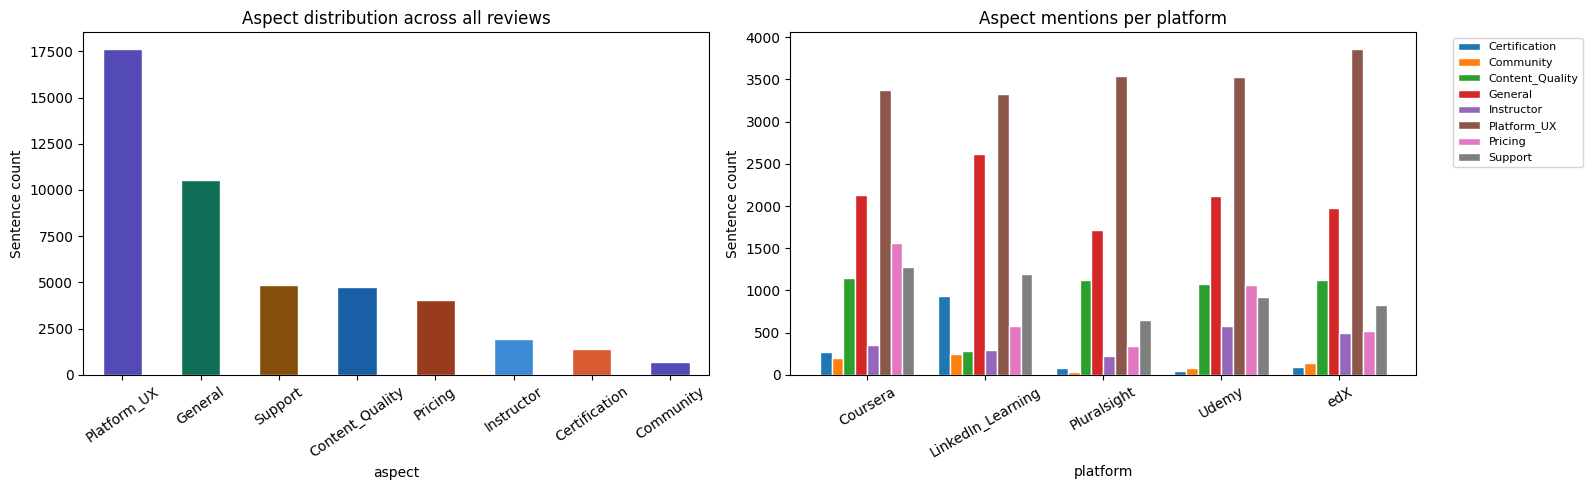

Chart saved to Drive!


In [14]:
import matplotlib.pyplot as plt

aspect_counts = df_sentences['aspect'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: overall aspect distribution
aspect_counts.plot(
    kind='bar', ax=axes[0],
    color=['#534AB7','#0F6E56','#854F0B','#185FA5','#993C1D','#3B8BD4','#D85A30'],
    edgecolor='white'
)
axes[0].set_title('Aspect distribution across all reviews')
axes[0].set_ylabel('Sentence count')
axes[0].tick_params(axis='x', rotation=35)

# Plot 2: aspect coverage per platform
platform_aspect = df_sentences.groupby(
    ['platform', 'aspect']
).size().unstack(fill_value=0)

platform_aspect.plot(
    kind='bar', ax=axes[1],
    edgecolor='white', width=0.8
)
axes[1].set_title('Aspect mentions per platform')
axes[1].set_ylabel('Sentence count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/aspect_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Drive!")

In [15]:
# Quick check — run this in NB02 after Cell 5
print(df_sentences.columns.tolist())
print("\nSample rows:")
print(df_sentences[['platform', 'sentence', 'aspect']].head(10))

['platform', 'country', 'region', 'review_id', 'text', 'rating', 'date', 'thumbs_up', 'text_clean', 'word_count', 'sentence', 'aspect_kw', 'aspect_zs', 'aspect']

Sample rows:
   platform                                           sentence  \
0  Coursera  i really like the idea of further learning, bu...   
1  Coursera          but then their not able to link accounts.   
2  Coursera  or denying refunds on transactions they again ...   
3  Coursera  i was going to rate after i finished my course...   
4  Coursera                    but, they messed with my money.   
5  Coursera                   not difficult to rate them then.   
6  Coursera  coursera used to be such a great website and app.   
7  Coursera  but as of a few months ago they got rid of vir...   
8  Coursera  before, you could learn a course for free but ...   
9  Coursera    now you can only learn the first week for free.   

            aspect  
0  Content_Quality  
1          General  
2          Pricing  
3    Certific